In [32]:


import os

base_dir =  r"C:\Users\Ahmed Hatem\Desktop\Graduation Project\diabetes tongue dataset"  # <- your new dataset path
train_dir = os.path.join(base_dir, 'output_train')
val_dir   = os.path.join(base_dir, 'output_valid')

print("Train folders:", os.listdir(train_dir))
print("Validation folders:", os.listdir(val_dir))



Train folders: ['diabetes', 'non_diabetes']
Validation folders: ['diabetes', 'non_diabetes']


In [33]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE = 224  # PyTorch expects int, not tuple
BATCH_SIZE = 32

train_dir = r"C:\Users\Ahmed Hatem\Desktop\Graduation Project\diabetes tongue dataset\output_train"
val_dir   = r"C:\Users\Ahmed Hatem\Desktop\Graduation Project\diabetes tongue dataset\output_valid"
test_dir  = r"C:\Users\Ahmed Hatem\Desktop\Graduation Project\diabetes tongue dataset\test"

# Keep your augmentation exactly the same
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
  transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
     transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data   = datasets.ImageFolder(val_dir, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_data.classes)


Classes: ['diabetes', 'non_diabetes']


In [6]:
import torch
import torch.nn as nn
from torchvision import models

# -----------------------------
# 1️⃣ Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 2️⃣ Load pretrained MobileNetV2
# -----------------------------
base_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Freeze backbone initially
for param in base_model.features.parameters():
    param.requires_grad = False

# -----------------------------
# 3️⃣ Build classifier head
# -----------------------------
class DiabetesClassifier(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model.features                       # MobileNetV2 backbone
        self.pool = nn.AdaptiveAvgPool2d(1)                  # Global Average Pooling
        self.bn1 = nn.BatchNorm1d(base_model.last_channel)
        self.dropout1 = nn.Dropout(0.4)
        self.fc1 = nn.Linear(base_model.last_channel, 128)  # Dense layer
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        self.output = nn.Linear(128, 1)                     # Raw logits

    def forward(self, x):
        x = self.base(x)
        x = self.pool(x).view(x.size(0), -1)  # flatten
        x = self.bn1(x)
        x = self.dropout1(x)
        x = self.fc1(x)
        x = nn.ReLU()(x)
        x = self.bn2(x)
        x = self.dropout2(x)
        x = self.output(x)                    # raw logits, NO Sigmoid
        return x

# -----------------------------
# 4️⃣ Instantiate model
# -----------------------------
model = DiabetesClassifier(base_model).to(device)

# -----------------------------
# 5️⃣ Optimizer + Loss
# -----------------------------
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()  # Important: raw logits → stable


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\Abdelrahman/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:03<00:00, 3.93MB/s]


In [7]:
# Print the mapping from class names to numeric labels
print("Train classes:", train_data.class_to_idx)
print("Validation classes:", val_data.class_to_idx)


NameError: name 'train_data' is not defined

In [44]:
import numpy as np

# Get all labels
train_labels = [label for _, label in train_data.samples]
val_labels = [label for _, label in val_data.samples]

# Count number of images per class
train_counts = np.bincount(train_labels)
val_counts = np.bincount(val_labels)

print("Train counts:", train_counts)
print("Validation counts:", val_counts)


Train counts: [1547 1548]
Validation counts: [346 348]


Epoch 1/20 | Train Loss: 0.5053 | Val Loss: 0.3709 | Val Acc: 0.8660 | Val Recall: 0.8563
Epoch 2/20 | Train Loss: 0.3567 | Val Loss: 0.3173 | Val Acc: 0.8818 | Val Recall: 0.8966
Epoch 3/20 | Train Loss: 0.3232 | Val Loss: 0.2882 | Val Acc: 0.8905 | Val Recall: 0.8851
Epoch 4/20 | Train Loss: 0.3011 | Val Loss: 0.2706 | Val Acc: 0.8934 | Val Recall: 0.8994
Epoch 5/20 | Train Loss: 0.2840 | Val Loss: 0.2486 | Val Acc: 0.9020 | Val Recall: 0.9023
Epoch 6/20 | Train Loss: 0.2741 | Val Loss: 0.2419 | Val Acc: 0.9035 | Val Recall: 0.9080
Epoch 7/20 | Train Loss: 0.2482 | Val Loss: 0.2264 | Val Acc: 0.9107 | Val Recall: 0.9224
Epoch 8/20 | Train Loss: 0.2307 | Val Loss: 0.2113 | Val Acc: 0.9179 | Val Recall: 0.9138
Epoch 9/20 | Train Loss: 0.2272 | Val Loss: 0.2066 | Val Acc: 0.9207 | Val Recall: 0.9368
Epoch 10/20 | Train Loss: 0.2083 | Val Loss: 0.1914 | Val Acc: 0.9251 | Val Recall: 0.9310
Epoch 11/20 | Train Loss: 0.2076 | Val Loss: 0.1872 | Val Acc: 0.9337 | Val Recall: 0.9598
Epoch 12

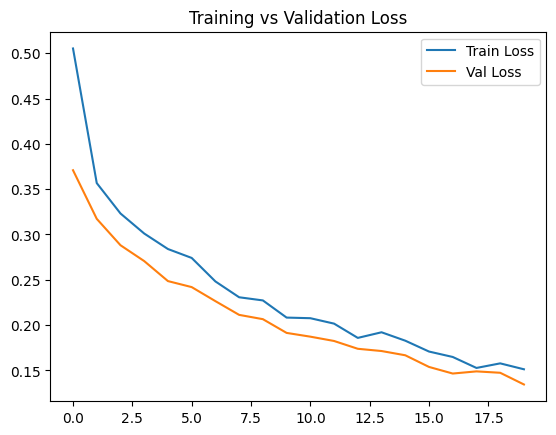

In [50]:
num_epochs = 20
train_losses, val_losses, val_accuracies, val_recalls = [], [], [], []

best_val_loss = float("inf")
patience = 5
patience_counter = 0

def save_checkpoint(model, path="best_model.pt"):
    torch.save(model.state_dict(), path)

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_train_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.float().to(device)
        optimizer.zero_grad()
        outputs = model(imgs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * imgs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation ----
    model.eval()
    running_val_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.float().to(device)
            outputs = model(imgs).squeeze()
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * imgs.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    val_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    val_recalls.append(recall_score(all_labels, all_preds))
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {val_accuracy:.4f} | "
          f"Val Recall: {val_recalls[-1]:.4f}")

    # ---- Early Stopping ----
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        save_checkpoint(model)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# ---- Load Best Model ----
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

# ---- Plot Loss Curves ----
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [51]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs).squeeze()

        # Because you used BCELoss (NOT BCEWithLogitsLoss)
        preds = (outputs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# -------------------
# Metrics
# -------------------
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nPrecision:", precision_score(all_labels, all_preds))
print("Recall:", recall_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds))

print("\nFull Classification Report:")
print(classification_report(all_labels, all_preds))


Confusion Matrix:
[[334  12]
 [ 17 331]]

Precision: 0.9650145772594753
Recall: 0.9511494252873564
F1 Score: 0.9580318379160637

Full Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       346
           1       0.97      0.95      0.96       348

    accuracy                           0.96       694
   macro avg       0.96      0.96      0.96       694
weighted avg       0.96      0.96      0.96       694



In [ ]:
import os

def get_all_files(folder):
    file_paths = []
    for root, dirs, files in os.walk(folder):
        for file in files:
            file_paths.append(os.path.relpath(os.path.join(root, file)))
    return set(file_paths)

train_files = get_all_files(train_dir)
val_files = get_all_files(val_dir)

overlap = train_files.intersection(val_files)
print("Total overlapping files:", len(overlap))

if len(overlap) > 0:
    print("Example overlaps:", list(overlap)[:5])


Total overlapping files: 0


In [ ]:
import torch
from torchvision import transforms
from PIL import Image


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 1️⃣ Load the best saved model
# -----------------------------
# Make sure your model class is defined exactly as before
model_path = r"D:/01Grad Project/Graduation-Project/DIabetes_image/best_model.pt"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()  # set to evaluation mode
model.to(device)

# -----------------------------
# 2️⃣ Define preprocessing (same as training)
# -----------------------------
IMG_SIZE = 224
preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# -----------------------------
# 3️⃣ Load a new image
# -----------------------------
img_path = r'D:/01Grad Project/Graduation-Project/test_diabetes_real.jpeg'
img = Image.open(img_path).convert("RGB")  # ensure 3 channels
img_tensor = preprocess(img).unsqueeze(0).to(device)  # add batch dimension

# -----------------------------
# 4️⃣ Predict
# -----------------------------
with torch.no_grad():
    output = model(img_tensor).item()  # sigmoid output
    predicted_label = 1 if output > 0.5 else 0

# -----------------------------
# 5️⃣ Map numeric label back to class name
# -----------------------------
class_mapping = train_data.class_to_idx  # {'diabetes':0, 'non_diabetes':1}
idx_to_class = {v:k for k,v in class_mapping.items()}
predicted_class = idx_to_class[predicted_label]

print(f"Predicted probability of non diabetes: {output:.4f}")
print(f"Predicted class: {predicted_class}")


FileNotFoundError: [Errno 2] No such file or directory: 'best_model.pt'

In [10]:
import torch
from torchvision import transforms
from PIL import Image


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 1️⃣ Load the best saved model
# -----------------------------
# Make sure your model class is defined exactly as before
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()  # set to evaluation mode
model.to(device)

# -----------------------------
# 2️⃣ Define preprocessing (same as training)
# -----------------------------
IMG_SIZE = 224
preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# -----------------------------
# 3️⃣ Load a new image
# -----------------------------
img_path = r'D:/01Grad Project/Graduation-Project/test_diabetes_real.jpeg'
img = Image.open(img_path).convert("RGB")  # ensure 3 channels
img_tensor = preprocess(img).unsqueeze(0).to(device)  # add batch dimension

# -----------------------------
# 4️⃣ Predict
# -----------------------------
with torch.no_grad():
    output = model(img_tensor).item()  # sigmoid output
    predicted_label = 1 if output > 0.5 else 0

# -----------------------------
# 5️⃣ Map numeric label back to class name
# -----------------------------
class_mapping = train_data.class_to_idx  # {'diabetes':0, 'non_diabetes':1}
idx_to_class = {v:k for k,v in class_mapping.items()}
predicted_class = idx_to_class[predicted_label]

print(f"Predicted probability of non diabetes: {output:.4f}")
print(f"Predicted class: {predicted_class}")


FileNotFoundError: [Errno 2] No such file or directory: 'best_model.pt'

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Get prediction probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels (threshold = 0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

# Full Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


AttributeError: 'DiabetesClassifier' object has no attribute 'predict'

In [1]:
# ---------- 1) recreate val generator with shuffle=False so labels align ----------
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os

base_dir = "/content/drive/MyDrive/diabetes_dataset/output_valid"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

val_datagen = ImageDataGenerator(rescale=1./255)

# recreate validation generator with shuffle=False so ordering is deterministic
val_data_fixed = val_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',    # binary because model uses sigmoid
    shuffle=False,
    seed=SEED
)

# ---------- 2) load best model if not already loaded ----------
from tensorflow.keras.models import load_model
# change path if your model filepath is different
best_model = load_model("/content/best_model.keras")

# ---------- 3) predict on validation set (full pass) ----------
steps = len(val_data_fixed)  # number of batches
y_true = val_data_fixed.classes  # ground truth labels in order
probs = best_model.predict(val_data_fixed, steps=steps, verbose=1)

# handle both shapes: (N,1) sigmoid or (N,2) softmax
if probs.ndim == 2 and probs.shape[1] == 1:
    y_prob_pos = probs.ravel()
    y_pred = (y_prob_pos > 0.5).astype(int)
elif probs.ndim == 2 and probs.shape[1] == 2:
    y_prob_pos = probs[:,1]
    y_pred = np.argmax(probs, axis=1)
else:
    y_prob_pos = probs.ravel()
    y_pred = (y_prob_pos > 0.5).astype(int)

# ---------- 4) classification report + confusion matrix ----------
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

print("CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, target_names=["diabetes","non_diabetes"], digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["diabetes","non_diabetes"],
            yticklabels=["diabetes","non_diabetes"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ---------- 5) ROC AUC (for the positive class) ----------
try:
    roc_auc = roc_auc_score(y_true, y_prob_pos)
    print(f"ROC AUC: {roc_auc:.4f}")
except Exception as e:
    print("ROC AUC could not be computed:", e)

# ---------- 6) Precision-Recall curve and PR AUC ----------
precision, recall, _ = precision_recall_curve(y_true, y_prob_pos)
pr_auc = auc(recall, precision)
plt.figure(figsize=(5,4))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend()
plt.show()

# ---------- 7) Plot training/validation accuracy & loss if 'history' exists ----------
if 'history' in globals():
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])
    epochs = range(1, len(acc)+1)
    if len(acc) > 0:
        plt.figure(figsize=(6,4))
        plt.plot(epochs, acc, label="Train acc")
        plt.plot(epochs, val_acc, label="Val acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.title("Accuracy")
        plt.show()
    if len(loss) > 0:
        plt.figure(figsize=(6,4))
        plt.plot(epochs, loss, label="Train loss")
        plt.plot(epochs, val_loss, label="Val loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title("Loss")
        plt.show()
else:
    print("No 'history' object found in environment — skip plotting training curves.")


FileNotFoundError: [WinError 3] The system cannot find the path specified: '/content/drive/MyDrive/diabetes_dataset/output_valid'